In [4]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import sys
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as patches
import matplotlib.animation as animation


In [2]:
ds_idealized_100d= xr.open_dataset('../snap_idealized_100d.cdf')

In [3]:
ds = ds_idealized_100d

In [15]:
def create_animation_for_dataset(dataset, dataset_name, save_animation=True, z_level=0):
    """Create animation for a single dataset"""
    
    variables = ['u', 'v', 'w', 'p']
    
    # Get time levels from the dataset
    t_levels = None
    for var in variables:
        if var in dataset:
            t_levels = dataset[var].shape[0]
            break
    
    if t_levels is None:
        print(f"Error: No valid variables found in dataset {dataset_name}")
        return None, None
    
    # Compute color limits per variable across all levels and times for this dataset
    color_limits = {}
    for var in variables:
        if var in dataset:
            data_all = dataset[var][:t_levels, z_level, :, :]  # shape (t, y, x)
            color_limits[var] = (np.nanmin(data_all), np.nanmax(data_all))
        else:
            print(f"Warning: Variable {var} not found in dataset {dataset_name}")
            color_limits[var] = (0, 1)  # fallback
    
    # Create figure and subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axes = axs.ravel()
    images = []
    
    # Initialize plots
    for ax, var in zip(axes, variables):
        if var in dataset:
            data = dataset[var][0, z_level, :, :]
            vmin, vmax = color_limits[var]
            
            # Choose appropriate colormap based on variable
            if var in ['u', 'v']:  # velocity components
                cmap = 'RdBu_r'
            elif var == 'w':  # vertical velocity
                cmap = 'seismic'
            else:  # pressure or other
                cmap = 'viridis'
                
            im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, 
                          aspect='auto', origin='lower')
            ax.set_title(f'{var} ({dataset_name})', fontsize=12, fontweight='bold')
            ax.set_xlabel('x (grid points)')
            ax.set_ylabel('y (grid points)')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=8)
            
        else:
            # Handle missing variable
            im = ax.imshow(np.zeros((10, 10)), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{var} (NOT AVAILABLE)', fontsize=12, color='red')
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=20, color='red')
            
        images.append(im)
    
    fig.suptitle(f'Dataset: {dataset_name} - Time step: 0', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    
    def update(frame):
        """Update function for animation"""
        updated_artists = []
        for i, var in enumerate(variables):
            if var in dataset:
                data = dataset[var][frame, z_level, :, :]
                images[i].set_data(data)
                updated_artists.append(images[i])
        
        fig.suptitle(f'Dataset: {dataset_name} - Time step: {frame}', 
                    fontsize=16, fontweight='bold')
        return updated_artists
    
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=t_levels, 
                                 interval=300, blit=False, repeat=True)
    
    if save_animation:
        # Create output directory
        output_dir = 'fig_idealized'
        os.makedirs(output_dir, exist_ok=True)
        """
        # Save as GIF (optional - requires pillow or imagemagick)
        try:
            gif_filename = os.path.join(output_dir, f'animation_{dataset_name}.gif')
            ani.save(gif_filename, writer='pillow', fps=3)
            print(f"Saved GIF animation: {gif_filename}")
        except Exception as e:
            print(f"Could not save GIF for {dataset_name}: {e}")
        """
        # Save as MP4 (optional - requires ffmpeg)
        try:
            mp4_filename = os.path.join(output_dir, f'animation_{dataset_name}_z={z_level}.mp4')
            ani.save(mp4_filename, writer='ffmpeg', fps=3, bitrate=1800)
            print(f"Saved MP4 animation: {mp4_filename}")
        except Exception as e:
            print(f"Could not save MP4 for {dataset_name}: {e}")
    
    return ani, fig

In [13]:
ds['z'][-1]

<xarray.DataArray 'z' ()> Size: 8B
array(1950.)
Coordinates:
    z        float64 8B 1.95e+03
Attributes:
    long_name:  z
    units:      m

Saved MP4 animation: fig_idealized/animation_idealized_100d_z=20.mp4


(<matplotlib.animation.FuncAnimation at 0x7fff91b0c0e0>,
 <Figure size 1400x1000 with 8 Axes>)

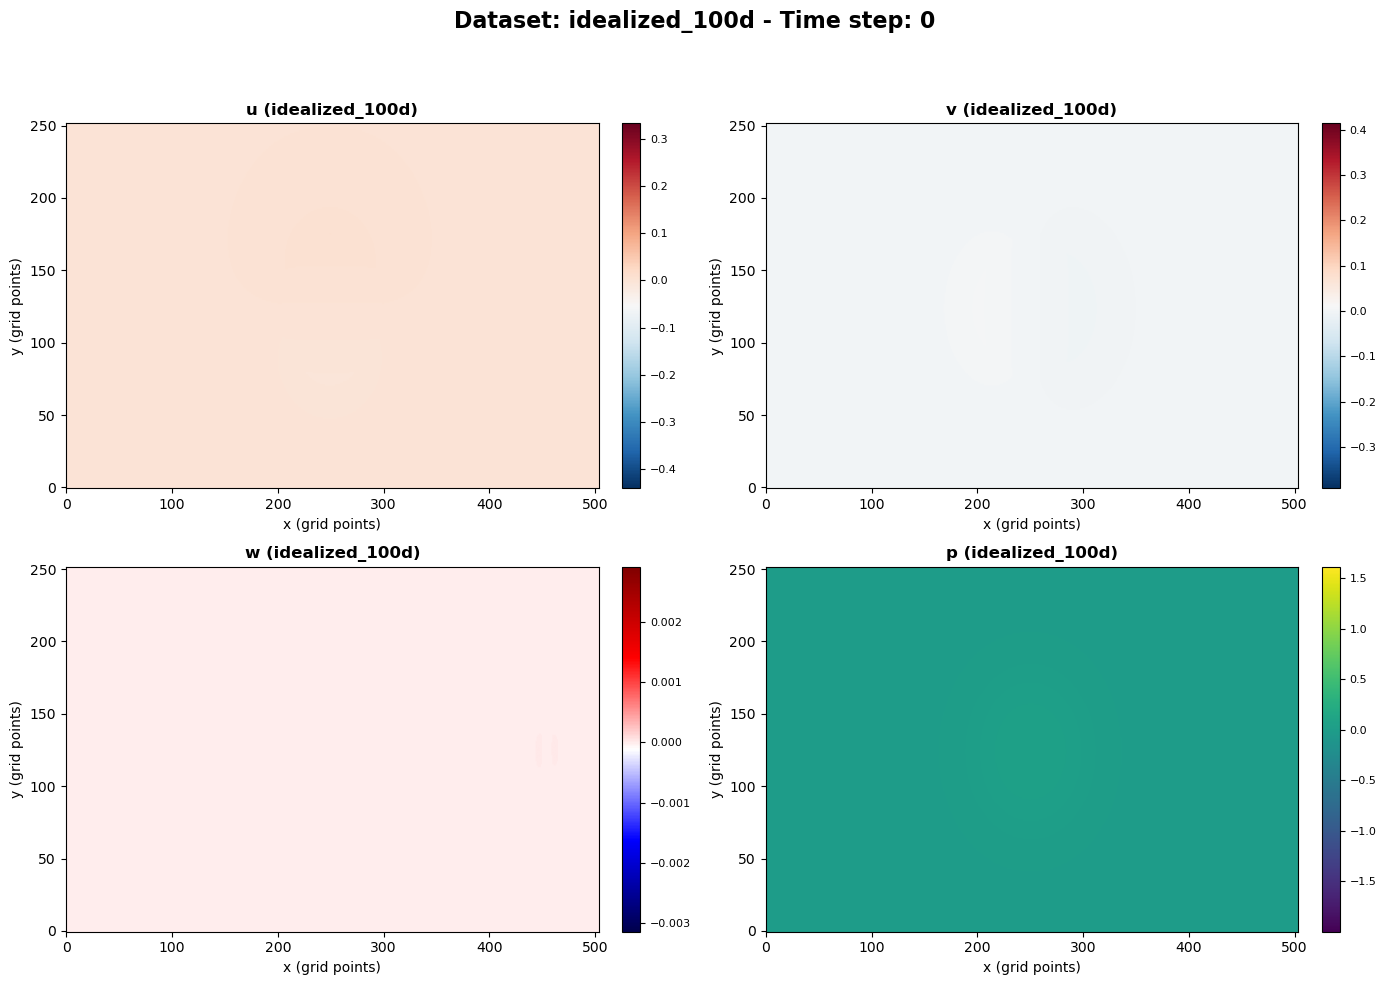

In [16]:
create_animation_for_dataset(ds, 'idealized_100d', z_level=20)

In [ ]:
# Band pass for internal tides
from scipy.signal import butter, lfilter

# cut off 
nyquist_freq = 1.0 / 2.0  # Nyquist frequency
#low_cutoff_freq = 1.0 / (15 )  
#high_cutoff_freq = 1.0 / (9 )  
low_cutoff_freq = 1.0 / (15 )  ## here the unit is hour, that means you have hourly data
high_cutoff_freq = 1.0 / (10 ) 
# low_cutoff_freq = 1.0 / (9 )  
# high_cutoff_freq = 1.0 / (3 )
order = 2  # Filter order 


def butter_bandpass(lowcut, highcut, nyquist_freq, order=2):
    low = lowcut / nyquist_freq
    high = highcut / nyquist_freq
    b, a = butter(order, [low, high], btype='band', analog=False)
    return b, a

b2, a2 = butter_bandpass(low_cutoff_freq, high_cutoff_freq, nyquist_freq, order=order)



ValueError: Digital filter critical frequencies must be 0 < Wn < 1

In [ ]:
u = ds.u[:,0,:,:].values
v = ds.v[:,0,:,:].values
w = ds.w[:,0,:,:].values
p = ds.p[:,0,:,:].values

bpu = lfilter(b2, a2, u, axis=0)
bpv = lfilter(b2, a2, v, axis=0)
bpw = lfilter(b2, a2, w, axis=0)
bpp = lfilter(b2, a2, p, axis=0)

In [ ]:
# apply the band-pass to the data
bpu4 = lfilter(b2, a2, ubc, axis=0)
print(bpu4.dtype)
bpv4 = lfilter(b2, a2, vbc, axis=0)
print(bpv4.dtype)
bpw4 = lfilter(b2, a2, w0, axis=0)
print(bpw4.dtype)
bpdens4 = lfilter(b2, a2, pdens0, axis=0)
print(bpdens4.dtype)


nyquist_freq = 1.0 / 2.0  # Nyquist frequency (half of the sampling frequency)
low_cutoff_freq = 1.0 / (62/24)  # High-pass cutoff frequency 
order = 2  # Filter order 

def butter_lowpass(lowcut, nyquist_freq, order=2):
    low = lowcut / nyquist_freq
    b, a = butter(order, low, btype='low', analog=False)
    return b, a

# low-pass filter
b2, a2 = butter_lowpass(low_cutoff_freq, nyquist_freq, order=order)

# Applying the low-pass filter
lpu4= lfilter(b2, a2, us1,axis=0)
print(lpu4.dtype)
lpv4 = lfilter(b2, a2, vs1,axis=0)
print(lpv4.dtype)